# Experiment 1 — First fiscal forecasting test

**Finding:** The original shallow tree does not beat persistence for operating performance. The primary evaluation covers three future years and 370 council-year predictions; the tree MAE is 7.400 versus 6.938 percentage points for persistence.

This short notebook reads saved, verified results and redraws the main comparison. It does not refit models. The complete fitting code is in [run_experiment.py](run_experiment.py).

## 1. Design

**Fiscal t−1 + disaster t → fiscal outcome t+1.** Train on earlier complete financial years, keeping the original one-year gap. Imputation is fitted within training folds; outcomes are never imputed. Operating performance is primary; cash cover and maintenance are separate secondary outcomes.

Original NSW panel, with boundary-flagged rows excluded. Persistence, training mean and a depth-3 tree with at least 20 training rows per leaf. Follow-up ridge diagnostics and accounting audits are in `audit/`.

MAE and RMSE measure error (lower is better); R² compares squared errors with the held-out mean and may be negative. Results are retrospective, not causal or proof of real-time forecast availability.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'NSW Data Panel.csv').exists())
folder = root / 'Experiment 1'
results = folder / 'results'
plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11})

## 2. Primary results

Operating-performance errors are in **percentage points**. All models within each experiment use identical held-out rows. The two experiments have different cohorts and years; their pooled scores are not a controlled before/after comparison.

In [2]:
summary = pd.read_csv(results / 'pooled_validation_metrics.csv')
annual = pd.read_csv(results / 'validation_metrics_long.csv')
primary = summary[summary.target.eq('operating_ratio_pct')]
primary[['model', 'n', 'MAE', 'RMSE', 'R2']].round(3)

,model,n,MAE,RMSE,R2
6,decision_tree,370,7.400,9.291,0.063
7,persistence,370,6.938,9.028,0.116
8,training_mean,370,7.517,9.991,-0.083


## 3. Does performance transfer across years?

Every evaluated primary-target year is shown. Lower lines indicate smaller errors; a pooled improvement alone does not establish a consistent win.

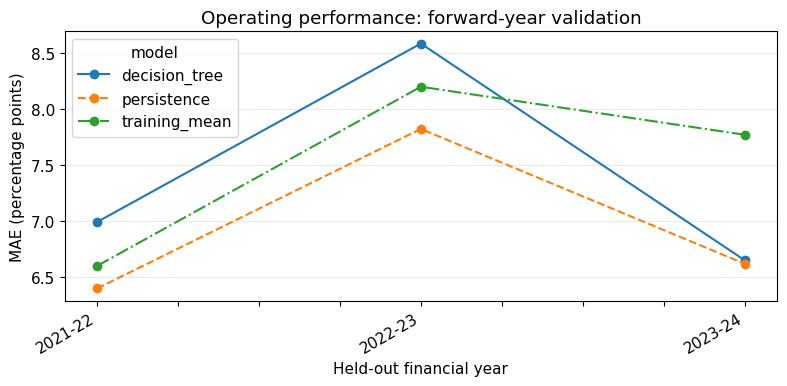

In [3]:
yearly = annual[annual.target.eq('operating_ratio_pct')].copy()
errors = yearly.pivot(index='test_fy', columns='model', values='MAE')
ax = errors.plot(marker='o', style=['-', '--', '-.', ':'][:len(errors.columns)])
ax.set(title='Operating performance: forward-year validation', xlabel='Held-out financial year', ylabel='MAE (percentage points)')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Secondary outcomes

In [4]:
summary[~summary.target.eq('operating_ratio_pct')][['target', 'model', 'n', 'MAE', 'RMSE', 'R2']].round(3)

,target,model,n,MAE,RMSE,R2
0,cash_cover_months,decision_tree,370,4.317,5.928,0.411
1,cash_cover_months,persistence,370,3.799,5.177,0.551
2,cash_cover_months,training_mean,370,5.685,7.869,-0.037
3,maintenance_ratio_pct,decision_tree,485,20.903,30.787,0.088
4,maintenance_ratio_pct,persistence,485,22.082,39.303,-0.487
5,maintenance_ratio_pct,training_mean,485,22.166,32.332,-0.006


**Interpretation:** Cash-cover prediction also loses to persistence. Maintenance was promising in the original small evaluation, but does not rescue the primary result. No disaster variable was selected by the original trees. The follow-up ridge diagnostics also failed to establish consistent superiority; see [the diagnostic verdict](audit/fiscal_diagnostics/research_verdict.md).

## 5. Conclusion and reproduction

**NO-GO for escalating model complexity on this evidence.** Few independent years, repeated councils, changing measurement and unknown exposure limit what can be concluded. This does not prove council finances are inherently unpredictable.

[Full results and limitations](results/README.md) · [All annual metrics](results/validation_metrics_long.csv)

To deliberately refit the original specification, run from AUSSEF:
```bash
python "Experiment 1/run_experiment.py"
```
The short notebook only reads those outputs. Historical notebooks are archived under `audit/`; input construction audits retain historical source paths documented in the project README.